# Assignment 03 - Part A

In [407]:
# import libraries
import geopandas as gpd

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

# we want to see all columns when we print a dataframe
pd.set_option('display.max_columns', None)

## A1 - Data acquisition and cleaning

Loading the GeoJSON and inspecting structure, types, and missingness

In [408]:
# CHATGPT-BEGIN: "how do I use geopandas to load a geojson file. 
# Load the GeoJSON with geopandas.read_file() 
# (gives you a ready-to-use geometry column)"
# https://chatgpt.com/share/6a6549b7-3200-83e8-adae-772e16ea8707
gdf = gpd.read_file("business-licences.geojson")
gdf.head()

,folderyear,licencersn,licencenumber,licencerevisionnumber,businessname,businesstradename,status,issueddate,expireddate,businesstype,businesssubtype,unit,unittype,house,street,city,province,country,postalcode,localarea,numberofemployees,feepaid,extractdate,geom,geo_point_2d,geometry
0,25,4637506,25-129785,00,(Anie Philip),NaN,Inactive,2024-11-26 05:02:01+00:00,2025-12-31,Long-term Rental,NaN,NaN,NaN,4959,Moss Street,Vancouver,BC,CA,V5R 3T5,Renfrew-Collingwood,0.0,94.0,2026-07-01 02:32:20-07:00,None,NaN,None
1,25,4637507,25-129786,00,(Tony Haughian),NaN,Issued,2024-11-18 17:52:13+00:00,2025-12-31,Long-term Rental,NaN,NaN,NaN,742,E 14th Av,Vancouver,BC,CA,V5T2N4,Mount Pleasant,0.0,226.0,2026-07-01 02:32:20-07:00,None,"{'lon': -123.088156984446, 'lat': 49.257735557...",POINT (-123.08816 49.25774)
2,25,4637508,25-129787,00,(Tony Haughian),NaN,Issued,2024-11-18 17:52:11+00:00,2025-12-31,Long-term Rental,NaN,NaN,NaN,2955,Fraser St,Vancouver,BC,CA,NaN,Mount Pleasant,0.0,275.0,2026-07-01 02:32:20-07:00,None,"{'lon': -123.08956400354, 'lat': 49.2580534457...",POINT (-123.08956 49.25805)
3,25,4637511,25-129790,00,Simone Deborah Avram (Simone Avram),NaN,Issued,2025-01-13 23:28:19+00:00,2025-12-31,Long-term Rental,NaN,NaN,NaN,405,E KING EDWARD AV,Vancouver,BC,CA,V5V 2C6,Riley Park,0.0,188.0,2026-07-01 02:32:20-07:00,None,"{'lon': -123.096461841129, 'lat': 49.248896343...",POINT (-123.09646 49.2489)
4,25,4637516,25-129795,00,(William Squibb),NaN,Issued,2025-02-10 02:52:10+00:00,2025-12-31,Long-term Rental,NaN,NaN,NaN,1862,Parker St,Vancouver,BC,CA,V5T 3Z3,Grandview-Woodland,0.0,437.0,2026-07-01 02:32:20-07:00,None,"{'lon': -123.066152409923, 'lat': 49.275460757...",POINT (-123.06615 49.27546)


Now, let's check the column names and the info for what we have in the database.

In [409]:
print("Columns:", gdf.columns)
gdf.info()

Columns: Index(['folderyear', 'licencersn', 'licencenumber', 'licencerevisionnumber',
       'businessname', 'businesstradename', 'status', 'issueddate',
       'expireddate', 'businesstype', 'businesssubtype', 'unit', 'unittype',
       'house', 'street', 'city', 'province', 'country', 'postalcode',
       'localarea', 'numberofemployees', 'feepaid', 'extractdate', 'geom',
       'geo_point_2d', 'geometry'],
      dtype='str')
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 204107 entries, 0 to 204106
Data columns (total 26 columns):
 #   Column                 Non-Null Count   Dtype                    
---  ------                 --------------   -----                    
 0   folderyear             204107 non-null  str                      
 1   licencersn             204107 non-null  str                      
 2   licencenumber          204107 non-null  str                      
 3   licencerevisionnumber  204107 non-null  str                      
 4   businessname      

From the data type information above, we can immediately see that there is a mismatch in the data types for the datatime columns `issueddate`, `expireddate` and `extractdate`. We'll fix this by removing the timezone info from `issuedate` and we can drop `extractdate` as that contains data about when the row was filled in. We do not need this for our analysis and clustering with this data.

We can also see that the `numberofemployees` is also float, which should not be possible as employees cannot be in decimals. We'll check this.

Other data types seem fairly correct.

In [410]:
# match datetime data types
gdf["issueddate"] = gdf["issueddate"].dt.tz_localize(None)

# drop extracted date column
gdf = gdf.drop(columns=["extractdate"])

In [411]:
gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 204107 entries, 0 to 204106
Data columns (total 25 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   folderyear             204107 non-null  str           
 1   licencersn             204107 non-null  str           
 2   licencenumber          204107 non-null  str           
 3   licencerevisionnumber  204107 non-null  str           
 4   businessname           190635 non-null  str           
 5   businesstradename      77307 non-null   str           
 6   status                 204107 non-null  str           
 7   issueddate             175295 non-null  datetime64[ms]
 8   expireddate            175319 non-null  datetime64[ms]
 9   businesstype           204107 non-null  str           
 10  businesssubtype        21518 non-null   str           
 11  unit                   48914 non-null   str           
 12  unittype               48650 non-nul

In [412]:
# check if any values in the number of employees column are not whole numbers
(gdf['numberofemployees'] % 1 != 0).any()

np.False_

Alright, so we checked if any values in the `numberofemployees` column are decimals and they are not, so the data is correct here.

Now let's check how the geometry column looks, generated by the geopandas library.

In [413]:
print("Geometry:\n", gdf.geometry)
print("Shape:", gdf.shape)

Geometry:
 0                                None
1         POINT (-123.08816 49.25774)
2         POINT (-123.08956 49.25805)
3          POINT (-123.09646 49.2489)
4         POINT (-123.06615 49.27546)
                     ...             
204102    POINT (-123.12087 49.27456)
204103    POINT (-123.06919 49.24731)
204104    POINT (-123.09108 49.22869)
204105                           None
204106    POINT (-123.10543 49.28398)
Name: geometry, Length: 204107, dtype: geometry
Shape: (204107, 25)


Adding longitude and latitude columns from the geometry column to the dataframe:

In [414]:
# create the longitude and latitude columns from the geometry column

# CHATGPT-BEGIN: "I want to add latitude and longitude from the geometry column into gdf"
# https://chatgpt.com/share/6a6549b7-3200-83e8-adae-772e16ea8707
gdf["longitude"] = gdf.geometry.x
gdf["latitude"] = gdf.geometry.y
# CHATGPT-END

gdf.head()

,folderyear,licencersn,licencenumber,licencerevisionnumber,businessname,businesstradename,status,issueddate,expireddate,businesstype,businesssubtype,unit,unittype,house,street,city,province,country,postalcode,localarea,numberofemployees,feepaid,geom,geo_point_2d,geometry,longitude,latitude
0,25,4637506,25-129785,00,(Anie Philip),NaN,Inactive,2024-11-26 05:02:01,2025-12-31,Long-term Rental,NaN,NaN,NaN,4959,Moss Street,Vancouver,BC,CA,V5R 3T5,Renfrew-Collingwood,0.0,94.0,None,NaN,None,NaN,NaN
1,25,4637507,25-129786,00,(Tony Haughian),NaN,Issued,2024-11-18 17:52:13,2025-12-31,Long-term Rental,NaN,NaN,NaN,742,E 14th Av,Vancouver,BC,CA,V5T2N4,Mount Pleasant,0.0,226.0,None,"{'lon': -123.088156984446, 'lat': 49.257735557...",POINT (-123.08816 49.25774),-123.088157,49.257736
2,25,4637508,25-129787,00,(Tony Haughian),NaN,Issued,2024-11-18 17:52:11,2025-12-31,Long-term Rental,NaN,NaN,NaN,2955,Fraser St,Vancouver,BC,CA,NaN,Mount Pleasant,0.0,275.0,None,"{'lon': -123.08956400354, 'lat': 49.2580534457...",POINT (-123.08956 49.25805),-123.089564,49.258053
3,25,4637511,25-129790,00,Simone Deborah Avram (Simone Avram),NaN,Issued,2025-01-13 23:28:19,2025-12-31,Long-term Rental,NaN,NaN,NaN,405,E KING EDWARD AV,Vancouver,BC,CA,V5V 2C6,Riley Park,0.0,188.0,None,"{'lon': -123.096461841129, 'lat': 49.248896343...",POINT (-123.09646 49.2489),-123.096462,49.248896
4,25,4637516,25-129795,00,(William Squibb),NaN,Issued,2025-02-10 02:52:10,2025-12-31,Long-term Rental,NaN,NaN,NaN,1862,Parker St,Vancouver,BC,CA,V5T 3Z3,Grandview-Woodland,0.0,437.0,None,"{'lon': -123.066152409923, 'lat': 49.275460757...",POINT (-123.06615 49.27546),-123.066152,49.275461


Now, let's check the missingness.

In [415]:
gdf.isnull().sum()

folderyear                    0
licencersn                    0
licencenumber                 0
licencerevisionnumber         0
businessname              13472
businesstradename        126800
status                        0
issueddate                28812
expireddate               28788
businesstype                  0
businesssubtype          182589
unit                     155193
unittype                 155457
house                     94403
street                    94386
city                         56
province                     80
country                   44874
postalcode                95141
localarea                  2714
numberofemployees             0
feepaid                   75460
geom                     204107
geo_point_2d             101541
geometry                 101541
longitude                101541
latitude                 101541
dtype: int64

We can see that the values in the geom column does not exist for the entire dataset, so this column can be dropped entirely. Nearly only half of the records have values for `geo_point_2d` and in turn, `geometry`.

Let's try to see what percentage of all values in each column are missing.

In [416]:
gdf.isna().mean().sort_values(ascending=False)

geom                     1.000000
businesssubtype          0.894575
unittype                 0.761645
unit                     0.760351
businesstradename        0.621243
latitude                 0.497489
longitude                0.497489
geometry                 0.497489
geo_point_2d             0.497489
postalcode               0.466133
house                    0.462517
street                   0.462434
feepaid                  0.369708
country                  0.219855
issueddate               0.141161
expireddate              0.141044
businessname             0.066005
localarea                0.013297
province                 0.000392
city                     0.000274
businesstype             0.000000
licencersn               0.000000
numberofemployees        0.000000
status                   0.000000
licencerevisionnumber    0.000000
licencenumber            0.000000
folderyear               0.000000
dtype: float64

As we are going to be plotting these businesses on a map, any business without valid geometry values, longitude, latitude, will be dropped as they cannot be plotted on the map without these values. So let's do that first.

In [417]:
# dropping rows with missing values in the geometry column
gdf = gdf.dropna(subset=['geometry'])
gdf = gdf.drop(columns=["geom"]) # drop the empty geom column

In [418]:
gdf.shape

(102566, 26)

We should also filter the dataset based on the `status` column. Let's check the distinct values it contains.

In [419]:
gdf["status"].value_counts()

status
Issued                  85917
Pending                  5912
Gone Out of Business     4800
Inactive                 4135
Cancelled                1802
Name: count, dtype: int64

Based on the above value counts and categories for status, we should only keep the business that are `Issued` / active for our EDA, and filter out all that are inactive, pending, gone out of business or cancelled. It's also mentioned on the open data portal for this dataset that:

> All existing business licences are transitioned automatically into the new categories. Some business licence categories retained the same name. Business owners will renew their licence at the end of each year and may select a different category from the one they were sorted into. New businesses applying for a licence af​ter the update will also select from the updated categories.

As this hints at possible duplicate entries for businesses, it makes sense to avoid these duplicates and keep only the businesses with licences that are curent, active and `Issued`.

In [420]:
gdf = gdf[gdf["status"] == "Issued"]

We've significantly shrunk the dataset this way according to our needs, ie:

1. Businesses with valid geometry to pin on a map.
2. Businesses that are active / have issued licences.

We have also possibly dropped rows with data errors as well. Let's check what the missingness looks like now.

In [421]:
gdf.isnull().sum()

folderyear                   0
licencersn                   0
licencenumber                0
licencerevisionnumber        0
businessname                 3
businesstradename        42959
status                       0
issueddate                 146
expireddate                147
businesstype                 0
businesssubtype          69699
unit                     48674
unittype                 48859
house                        0
street                       0
city                         0
province                     0
country                   8828
postalcode                 654
localarea                    0
numberofemployees            0
feepaid                  26481
geo_point_2d                 0
geometry                     0
longitude                    0
latitude                     0
dtype: int64

In [422]:
gdf.isna().mean().sort_values(ascending=False)

businesssubtype          0.811236
unittype                 0.568677
unit                     0.566524
businesstradename        0.500006
feepaid                  0.308216
country                  0.102750
postalcode               0.007612
expireddate              0.001711
issueddate               0.001699
businessname             0.000035
folderyear               0.000000
longitude                0.000000
geometry                 0.000000
geo_point_2d             0.000000
numberofemployees        0.000000
localarea                0.000000
house                    0.000000
province                 0.000000
city                     0.000000
street                   0.000000
licencersn               0.000000
businesstype             0.000000
status                   0.000000
licencerevisionnumber    0.000000
licencenumber            0.000000
latitude                 0.000000
dtype: float64

So now, most of the columns do not have missing values. However, `businesssubtype` has 80.6% missing values, `unittype/unit` has ~56%, `businesstradename` has 50.0% and `feepaid` has 30.8%, with >= 10% for `country`,  `postalcode`, `expireddate`, `issueddate`, and `businessname`.

We can combine `businesssubtype` and `businesstype` and refine the values to deal with the missing values.

As `businessname` only has three missing values, we can keep it as it is. However, we can drop the businesstradename column due to the large amount of missing values it has, and its similarity with `businessname`.

As we have also filtered this dataset to contain only `Issued` licences, the `status` column becomes redundant as all values in it are now `Issued` and it does not provide additional information now.

As we are plotting this data using the latitude, and longitude values, do not need `geo_point_2d` and `geometry` as we have extracted the latitude and longitude from them.

We know that the `city`, `province` and `country` column only has one unique value, so these columns can be dropped as well, as we are aware that all of these business are located in "Vancouver, BC, CA". These columns do not provide additional information. This data is retained by the `longitude` and `latitude` values when pinned on the map anyway. We can also drop `unit` and `unit type` as address level data is not truly needed for our purpose when we have lat/long available.

As for the rest, like `feepaid` and `numberofemployees` we cannot assume their values to be the `mean` or `median` of the data, as when these are plotted/clustered on the map and can give inaccurate results. We cannot assume values for issued and expired dates as well. Hence, we'll keep the following columns as they are with their missingness for now:

- feepaid
- postalcode
- expireddate
- issueddate

Let's drop the mentioned columns first.

In [423]:
gdf = gdf.drop(columns=["status", "businesstradename", "geo_point_2d", "geometry", "unittype", "unit", "country", "province", "city"])

Let's consolidate businesstype and businesssubtype into one column. We can drop the `businesssubtype` column then, as we will not need it.

In [424]:
gdf["businesstype"] = gdf["businesstype"].fillna(gdf["businesssubtype"])
gdf = gdf.drop(columns=["businesssubtype"])
gdf["businesstype"].isna().mean()

np.float64(0.0)

In [425]:
# columns left:
gdf.columns

Index(['folderyear', 'licencersn', 'licencenumber', 'licencerevisionnumber',
       'businessname', 'issueddate', 'expireddate', 'businesstype', 'house',
       'street', 'postalcode', 'localarea', 'numberofemployees', 'feepaid',
       'longitude', 'latitude'],
      dtype='str')

Now let's continue with the EDA by looking at statistics for the remaining valid data, before we consolidate business names and types.

In [426]:
gdf.describe() # checking the numerical cols and any datetime ones

,issueddate,expireddate,numberofemployees,feepaid,longitude,latitude
count,85771,85770,85917.000000,59436.000000,85917.000000,85917.000000
mean,2025-01-14 01:31:02.709000,2025-12-30 08:45:10.766000,18.042075,663.163052,-123.112159,49.265653
min,2023-11-04 00:55:04,2024-01-12 00:00:00,0.000000,2.000000,-123.219197,49.200531
25%,2024-01-16 20:11:34.500000,2024-12-31 00:00:00,1.000000,265.000000,-123.128040,49.259820
50%,2024-12-20 01:01:35,2025-12-31 00:00:00,3.000000,277.000000,-123.117276,49.269146
75%,2025-11-26 19:04:42.500000,2026-12-31 00:00:00,9.000000,490.000000,-123.098428,49.282575
max,2026-10-01 18:30:13,2027-12-31 00:00:00,5876.000000,63722.000000,-123.024016,49.298055
std,NaN,NaN,103.190890,1518.319808,0.032212,0.021537


In [427]:
gdf.describe(include="all")

,folderyear,licencersn,licencenumber,licencerevisionnumber,businessname,issueddate,expireddate,businesstype,house,street,postalcode,localarea,numberofemployees,feepaid,longitude,latitude
count,85917,85917,85917,85917,85914,85771,85770,85917,85917,85917,85263,85917,85917.000000,59436.000000,85917.000000,85917.000000
unique,3,85916,85908,7,30156,NaN,NaN,90,5206,880,5653,23,NaN,NaN,NaN,NaN
top,26,4876481,24-130885,00,Parking Corporation of Vancouver,NaN,NaN,Health Care Professionals and Services,1055,W BROADWAY,V5Z 4C2,Downtown,NaN,NaN,NaN,NaN
freq,29070,2,2,56672,349,NaN,NaN,11803,1222,6062,577,26883,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,2025-01-14 01:31:02.709000,2025-12-30 08:45:10.766000,NaN,NaN,NaN,NaN,NaN,18.042075,663.163052,-123.112159,49.265653
min,NaN,NaN,NaN,NaN,NaN,2023-11-04 00:55:04,2024-01-12 00:00:00,NaN,NaN,NaN,NaN,NaN,0.000000,2.000000,-123.219197,49.200531
25%,NaN,NaN,NaN,NaN,NaN,2024-01-16 20:11:34.500000,2024-12-31 00:00:00,NaN,NaN,NaN,NaN,NaN,1.000000,265.000000,-123.128040,49.259820
50%,NaN,NaN,NaN,NaN,NaN,2024-12-20 01:01:35,2025-12-31 00:00:00,NaN,NaN,NaN,NaN,NaN,3.000000,277.000000,-123.117276,49.269146
75%,NaN,NaN,NaN,NaN,NaN,2025-11-26 19:04:42.500000,2026-12-31 00:00:00,NaN,NaN,NaN,NaN,NaN,9.000000,490.000000,-123.098428,49.282575
max,NaN,NaN,NaN,NaN,NaN,2026-10-01 18:30:13,2027-12-31 00:00:00,NaN,NaN,NaN,NaN,NaN,5876.000000,63722.000000,-123.024016,49.298055


The open data portal mentions that `licencersn` might have duplicate values, let's check and remove any that exist.

In [428]:
counts = gdf['licencersn'].value_counts()
counts[counts > 1]

licencersn
4876481    2
Name: count, dtype: int64

In [429]:
gdf[gdf.duplicated(subset=['licencersn'], keep=False)]

,folderyear,licencersn,licencenumber,licencerevisionnumber,businessname,issueddate,expireddate,businesstype,house,street,postalcode,localarea,numberofemployees,feepaid,longitude,latitude
52908,26,4876481,26-153897,00,IMX PORT TRADING INC.,2026-03-31 17:21:25,2026-12-31,Retail Dealer,595,BURRARD ST,V6C 1A0,Downtown,1.0,634.0,-123.11973,49.28613
128093,26,4876481,26-153897,00,IMX PORT TRADING INC.,2026-03-31 17:21:25,2026-12-31,Retail Dealer,595,BURRARD ST,V6C 1A0,Downtown,1.0,634.0,-123.11973,49.28613


Hence, let's drop record 52908, as it has missing `unit` data that the other record contains.

In [430]:
gdf = gdf.drop(52908)
counts = gdf['licencersn'].value_counts()
counts[counts > 1]

Series([], Name: count, dtype: int64)

Alright the only duplicate for `licencersn` has been dropped.

In [431]:
gdf['postalcode']

1          V5T2N4
2             NaN
3         V5V 2C6
4         V5T 3Z3
5         V5L 1Y5
           ...   
204099    V6K 3C5
204100    V6K 1P9
204102    V6Z 2R8
204103    V5N 2S4
204106    V6B 1A1
Name: postalcode, Length: 85916, dtype: str

Looking at some of the code results, tables and data descriptions above, we can see that some cols have extremely large amounts of missing values. 

And some discrepencies exist when you look at the number of unique values for each column. For example:

- `folderyear` has 3 unique values -> the data from a total of 3 years has been collected.
- Some duplicate values also exist for `licencenumber` due to revisions, so they can remain in the dataset as they are, since all of these duplicates have unique `licencersn` identifiers.
- 90 unique `businesstype`s exist and 76 unique `businesssubtype`s exist.
- We also have some postal code formatting issues where `postalcode` is formatted without a space after the first 3 letter like: `V5T2N4`, instead of `V5T 2N4`.

Let's fix postal code formatting first.

In [432]:
# CHATGPT-BEGIN: "how do I make sure if postal code doesn't have a space in between
# I can add it and not do it for the rest of the correct values. 
# like V5T2N4 to V5T 2N4"
# https://chatgpt.com/share/6a6549b7-3200-83e8-adae-772e16ea8707
gdf["postalcode"] = gdf["postalcode"].str.replace(
    r"^([A-Za-z]\d[A-Za-z])(\d[A-Za-z]\d)$",
    r"\1 \2",
    regex=True
)
#CHATGPT-END

gdf['postalcode']

1         V5T 2N4
2             NaN
3         V5V 2C6
4         V5T 3Z3
5         V5L 1Y5
           ...   
204099    V6K 3C5
204100    V6K 1P9
204102    V6Z 2R8
204103    V5N 2S4
204106    V6B 1A1
Name: postalcode, Length: 85916, dtype: str

In [433]:
gdf.head()

,folderyear,licencersn,licencenumber,licencerevisionnumber,businessname,issueddate,expireddate,businesstype,house,street,postalcode,localarea,numberofemployees,feepaid,longitude,latitude
1,25,4637507,25-129786,00,(Tony Haughian),2024-11-18 17:52:13,2025-12-31,Long-term Rental,742,E 14th Av,V5T 2N4,Mount Pleasant,0.0,226.0,-123.088157,49.257736
2,25,4637508,25-129787,00,(Tony Haughian),2024-11-18 17:52:11,2025-12-31,Long-term Rental,2955,Fraser St,NaN,Mount Pleasant,0.0,275.0,-123.089564,49.258053
3,25,4637511,25-129790,00,Simone Deborah Avram (Simone Avram),2025-01-13 23:28:19,2025-12-31,Long-term Rental,405,E KING EDWARD AV,V5V 2C6,Riley Park,0.0,188.0,-123.096462,49.248896
4,25,4637516,25-129795,00,(William Squibb),2025-02-10 02:52:10,2025-12-31,Long-term Rental,1862,Parker St,V5T 3Z3,Grandview-Woodland,0.0,437.0,-123.066152,49.275461
5,25,4637520,25-129799,00,(Daniel Dittrich),2024-11-25 05:13:44,2025-12-31,Long-term Rental,2204,FERNDALE ST,V5L 1Y5,Grandview-Woodland,0.0,282.0,-123.059579,49.279366


Let's also now consolidate business types with business sub type, and then only keep the categories that refer to 80-90% of the businesses.

In [434]:
gdf["businesstype"].value_counts()

businesstype
Health Care Professionals and Services    11803
Long-term Rental                          10266
Retail Dealer                              6136
Legal Services                             5211
Restaurant                                 4914
                                          ...  
Urban Farm Class B                            4
Adult Services                                3
Amusement Park                                3
Oil Gas and Other Fuels                       3
Marine Service Station                        3
Name: count, Length: 90, dtype: int64

In [435]:
# let's see the sum of the percentages of the top values, and how many sum up to 80-90%
(gdf["businesstype"].value_counts().head(25) / gdf.shape[0] * 100).sum()

np.float64(84.02742213324642)

Hence, let's keep the top 25 categories that amount to nearly 84% of the business types and group the rest as others.

In [436]:
# CHATGPT-BEGIN: "how do I make sure all values that are not in the top 25
#  are changed to "Other". gdf["businesstype"].value_counts().head(25)"
# https://chatgpt.com/share/6a658b5b-ad14-83e8-a3b4-a16aaedc4cb5

top_25 = gdf["businesstype"].value_counts().head(25).index

gdf["businesstype"] = gdf["businesstype"].where(
    gdf["businesstype"].isin(top_25),
    "Other"
)

gdf["businesstype"].value_counts()

businesstype
Other                                            13723
Health Care Professionals and Services           11803
Long-term Rental                                 10266
Retail Dealer                                     6136
Legal Services                                    5211
Restaurant                                        4914
Beauty Services                                   3940
Limited Service Food Establishment                3814
Business Support Services                         2960
Financial Services                                2401
Consulting and Management Services                2353
Real Estate Services                              2055
Retail Dealer - Food                              1935
General Contractor                                1789
Association or Society                            1724
Information Communication Technology              1706
Wholesale Dealer - Non-Food                       1456
Parking Area / Garage                             11

Hence, we can see that the top 25 categories remain that encompass nearly 84% of businesses, while the rest have been grouped as "Other" with nearly 14328 businesses.

## A2 - Location-only clustering: K-means vs. DBSCAN

In [437]:
cluster_data = gdf.copy()
coords = cluster_data[["latitude", "longitude"]].to_numpy()

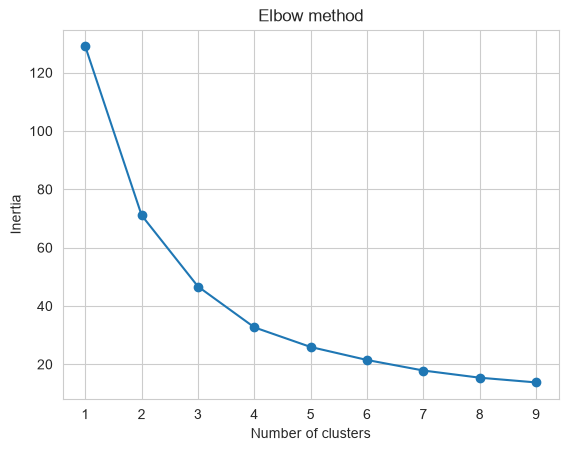

In [438]:
inertias = []

for i in range(1, 10):
    km = KMeans(n_clusters=i, n_init=10, random_state=42)
    km.fit(coords)
    inertias.append(km.inertia_)

plt.plot(list(range(1, 10)), inertias, marker="o")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.title("Elbow method")
plt.show()

Picking number of clusters as 4 as after 4, the slope decreases at an almost constant rate.

dbscan_cluster
 0    84897
 3      419
 2      245
 5      127
-1       62
 9       47
 7       35
 4       34
 1       28
 8       12
 6       10
Name: count, dtype: int64


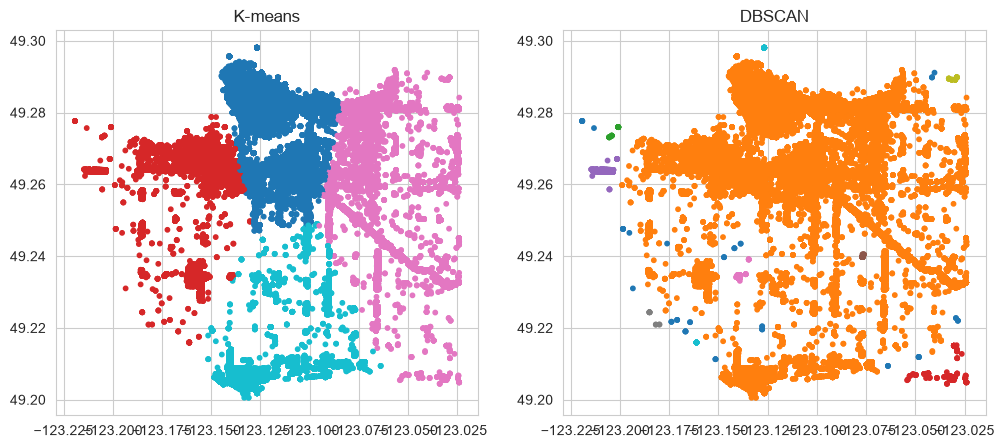

In [439]:
n = 4  # picked based on the above plot
kmeans = KMeans(n_clusters=n, n_init=10, random_state=42)
cluster_data["kmeans_cluster"] = kmeans.fit_predict(coords)

dbscan = DBSCAN(eps=0.005, min_samples=10) # picked after some trail and error
cluster_data["dbscan_cluster"] = dbscan.fit_predict(coords)
print(cluster_data["dbscan_cluster"].value_counts())

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].scatter(cluster_data["longitude"], cluster_data["latitude"], c=cluster_data["kmeans_cluster"], cmap="tab10", s=10)
ax[0].set_title("K-means")

ax[1].scatter(cluster_data["longitude"], cluster_data["latitude"], c=cluster_data["dbscan_cluster"], cmap="tab10", s=10)
ax[1].set_title("DBSCAN")

plt.show()

I chose the DBSCAN values through trail and error, and printing the value counts to ensure noise (-1) is as minimal compared to the actual clustered values.

> How do the K-means clusters map onto actual Vancouver geography — do they correspond to anything you'd recognize (downtown core, west side, etc.)?

Based on the k-means clusters, we can see that the 4 clusters divide up into west (red), north (blue), east (pink), and south (turquoise). Mapping this onto the actual map of vancouver (I looked it up on google maps), it seems like the north (blue) part of the cluster shows businesses based mostly in the Stanley Park / Granville Island area, and we can even see the False Creek area in this blue cluster where there are no business due to the water.

The west (red) cluster shows businesses in the West Point Grey and surrounding areas, where there are mostly forests and parks, hence business densities are sparse here, we can see on the plot as well.

The south (turquoise) part of the graph mostly shows the south vancouver area, with businesses mostly clustered around the Fraser River bay area.

The east (pink) part of the graph shows the Downtown eastside area where business are most clustered, and the Kingsway road which was business clustered around its sides, with some divergences into businessed based in Killarney, and Victoria-FraserView, and less density of clusters around the Everett Crowley Park area.

> How do the DBSCAN clusters compare? Where do the two methods agree or disagree, and why — think about what each algorithm assumes about cluster shape and density, and what DBSCAN's "noise" points represent.

The DBSCAN plot shows one giant orange cluster that dominates over almost every other points / clusters. It also shows a handful of small clusters such as the purple cluster on the far west edge, a couple green dots, a small red cluster bottom right and scattered noise points.

It seems K-means is creating equal sized clusters on the dataset, regaardless of distribution density, while DBSCAN is taking that density into consideration, and it shows us that the big orange cluster is businesses grouped together closely with equal density. The noise points show us where density varies. I think the orange cluster could represent all businesses tightly grouped toegther in downtown while all the other colored points (noise) are those that are physically separated from downtown, either by land, or bodies of water. The noise points are too isolated to belong to the same density cluster.

## A3 — Feature-based clustering: Size, Industry, Lifecycle

In [440]:
features = gdf.copy()

In [441]:
# size - number of employees, fee paid
features[["numberofemployees", "feepaid"]].isna().mean().sort_values(ascending=False)

feepaid              0.30822
numberofemployees    0.00000
dtype: float64

So we still have some values missing for feepaid, we can fill them using the mean for this data, as we are assuming we do not have outliers in the data.

In [442]:
features["feepaid"] = features["feepaid"].fillna(features["feepaid"].mean())

In [443]:
# lifecycle features

# we will drop rows with no expired or issue data as we cannot guess it
features = features.dropna(subset=['expireddate', 'issueddate'])

features["duration_days"] = (features["expireddate"] - features["issueddate"]).dt.days
features["issue_month"] = features["issueddate"].dt.month

# industry - encoding business type categories
industry_encoded = pd.get_dummies(features["businesstype"], prefix="type").to_numpy()

# CHATGPT-BEGIN: "what does month issued (cyclically encoded) mean"
# https://chatgpt.com/share/6a66e02d-e04c-83e8-837e-cbfddf8bcb84
features["issue_month_sin"] = np.sin(2 * np.pi * features["issue_month"] / 12)
features["issue_month_cos"] = np.cos(2 * np.pi * features["issue_month"] / 12)
# CHATGPT-END
# licence revision number is already in the dataset

In [444]:
numeric_cols = ["numberofemployees", "feepaid", "duration_days", "issue_month_sin", "issue_month_cos"]
numeric_scaled = StandardScaler().fit_transform(features[numeric_cols])

X = np.hstack([numeric_scaled, industry_encoded])
print(X.shape)

(85769, 31)


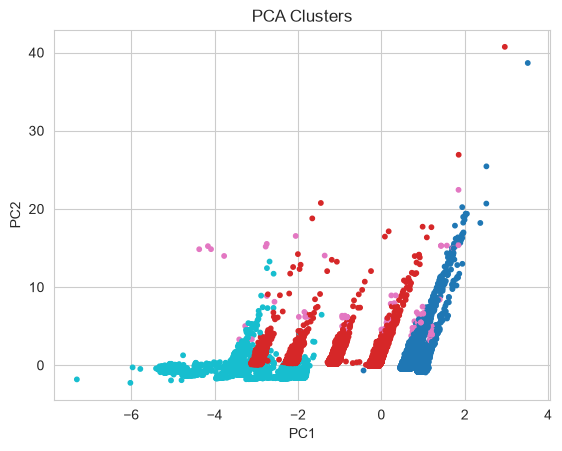

Explained variance ratio: [0.29752984 0.17825612]
Cumulative: 0.4757859611426091


In [445]:
km_features = KMeans(n_clusters=4, n_init=10, random_state=42)
features["feature_cluster"] = km_features.fit_predict(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=features["feature_cluster"], cmap="tab10", s=10)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Clusters")
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Cumulative:", np.cumsum(pca.explained_variance_ratio_)[1])

PC1 captures the industry category values, while PC2 captures the continuous numerical values we have. The clustered peaks in this graph are likely the encoded industry categories we engineered, and data is grouped across them. The sizes / lengths of these grouped peaks can be explained by the fee paid / number of employee / duration columns.

PC1 explains 29.7% of the data and PC2 explains 17% of the data. Combined, they explain nearly 47.5% of the data variations. 

The colored clusters here do not align with the k-means clusters. It seems like k-mean might not be clustering on the bases of industry / business type, but this PCA shows the clustering across industry types and durations / sizes. The points above 20 on the y-axis can be outliers with a very large number of employees, or fee paid, or durations, while most points are concentrated around the y = 0 line (which is the mean), and then, per business type, they are rising up from there.